In [14]:
import os
import pickle

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats

import onep  # your 1p analysis utilities

# Collections
FC_COLLECTION_PATH    = "/Users/suthardr/Desktop/collection_fc_allmice.pkl"
CXT_A_COLLECTION_PATH = "/Users/suthardr/Desktop/collection_cxta_allmice.pkl"
CXT_B_COLLECTION_PATH = "/Users/suthardr/Desktop/collection_cxtb_allmice.pkl"

# Recall Events
CXT_A_CSV_PATH = (
    "/Volumes/rkc_ramirezlab/Home/rsenne/dCA1_Clean_Data/"
    "revision_analysis/Figure3_Recall/num_events_Fig3/event_times_cxta.csv"
)

CXT_B_CSV_PATH = (
    "/Volumes/rkc_ramirezlab/Home/rsenne/dCA1_Clean_Data/"
    "revision_analysis/Figure3_Recall/num_events_Fig3/event_times_cxtb.csv"
)

# Output
BASE_FIG_DIR   = "/Users/suthardr/Desktop/Fig4"
HEATMAP_DIR_A  = os.path.join(BASE_FIG_DIR, "RecallA_sorted_FC_argmax")
HEATMAP_DIR_B  = os.path.join(BASE_FIG_DIR, "RecallB_sorted_FC_argmax")

os.makedirs(HEATMAP_DIR_A, exist_ok=True)
os.makedirs(HEATMAP_DIR_B, exist_ok=True)

# FC events & trace length
FC_EVENTS  = [120, 180, 240, 300]
N_SAMPLES  = 3303  # remove after 3303

# Lil functions
#load collections
def load_collections():
    with open(FC_COLLECTION_PATH, "rb") as f:
        collection_fc = pickle.load(f)
    with open(CXT_A_COLLECTION_PATH, "rb") as f:
        collection_cxta = pickle.load(f)
    with open(CXT_B_COLLECTION_PATH, "rb") as f:
        collection_cxtb = pickle.load(f)
    return collection_fc, collection_cxta, collection_cxtb
#load recall events and make a lil dictionary with the animal_id and event times
def load_recall_events(csv_path, suffix):
    df = pd.read_csv(csv_path)
    events_by_animal = {}
    for col in df.columns:
        animal = col.replace(suffix, "")
        events = df[col].dropna().tolist()
        events_by_animal[animal] = events
    return events_by_animal

#plot FC-Recall side by side heatmaps
def plot_heatmaps(sorted_arr_fc, sorted_arr_recall,
                  time_fc, time_recall,
                  animal, context_label, out_dir):
    first_last_fc = [0, sorted_arr_fc.shape[0]]
    first_last_recall = [0, sorted_arr_recall.shape[0]]

    fig, axs = plt.subplots(1, 2, figsize=(10, 7), sharey=True)

    # FC heatmap
    sns.heatmap(
        sorted_arr_fc, cmap="mako", cbar=False, ax=axs[0],
        vmin=-3, vmax=6, rasterized=True, annot=False
    )
    axs[0].axvline((time_fc.shape[0] / 3), linestyle="--", color="white")
    axs[0].tick_params(axis="both", which="major", labelsize=12)
    axs[0].set_xticks(np.linspace(0, sorted_arr_fc.shape[1], 5))
    axs[0].set_xticklabels(
        np.linspace(time_fc.min(), time_fc.max(), 5).astype(int),
        rotation=0
    )
    axs[0].set_yticks(first_last_fc)
    axs[0].set_yticklabels(first_last_fc, rotation=0)
    axs[0].set_title("FC Sorted by FC Argmax", fontsize=14)
    axs[0].set_xlabel("Time (s)", fontsize=14)
    axs[0].set_ylabel("Reactivated Cell #", fontsize=14)

    # Recall heatmap
    heatmap = sns.heatmap(
        sorted_arr_recall, cmap="mako", cbar=True, rasterized=True,
        cbar_kws={"label": r"z-scored $\frac{dF}{F}$"},
        ax=axs[1], vmin=-3, vmax=6, annot=False
    )
    axs[1].axvline((time_recall.shape[0] / 3), linestyle="--", color="white")
    axs[1].tick_params(axis="both", which="major", labelsize=12)
    axs[1].set_xticks(np.linspace(0, sorted_arr_recall.shape[1], 5))
    axs[1].set_xticklabels(
        np.linspace(time_recall.min(), time_recall.max(), 5).astype(int),
        rotation=0
    )
    axs[1].set_yticks(first_last_recall)
    axs[1].set_yticklabels(first_last_recall, rotation=0)
    axs[1].set_title(f"Recall {context_label} Sorted by FC Argmax", fontsize=14)
    axs[1].set_xlabel("Time (s)", fontsize=14)

    cbar = heatmap.collections[0].colorbar
    cbar.ax.yaxis.set_tick_params(labelsize=12)
    cbar.set_label(r"z-scored $\frac{dF}{F}$", fontsize=14)

    plt.tight_layout() #save the heatmaps as svg
    fname = f"{animal}_{context_label}_reactivated_sort_sequence.svg"
    fig.savefig(os.path.join(out_dir, fname))
    plt.close(fig)

#function to process all the animals
def process_animal(
    animal,
    collection_fc,
    collection_recall,
    recall_events,       #list of event times
    reg_key,             # "FC-A" or "FC-B"
    heatmap_dir,
    context_label        # "CxtA" or "CxtB"
):
    #prints progress
    print(f"\nProcessing {animal} ({context_label})...")

    #recall events (from correct CSV for this context)
    events_recall = recall_events.get(animal)
    if not events_recall:
        print("  No recall events in CSV, skipping.")
        return None

    #registration table (FC vs recall)
    try:
        reg = collection_fc.animals[animal].registration_tables[reg_key]
    except Exception as e:
        print(f"  No registration table {reg_key} for {animal}: {e}")
        return None

    reg = pd.DataFrame(reg)

    #check is this animal in this context if not warn me and skip
    if animal not in collection_recall.animals:
        print(f"  Recall traces for {animal} not found in this collection ({context_label}), skipping.")
        return None

    #id rej_ind from each session
    rejected_fc = pd.Series(collection_fc.animals[animal].rejected_inds)
    rejected_recall = pd.Series(collection_recall.animals[animal].rejected_inds)

    reg_fc_ok = reg[~reg[0].isin(rejected_fc)]
    reg_both_ok = reg_fc_ok[~reg_fc_ok[1].isin(rejected_recall)]

    # keep only indices (not -1) that were both days
    both_idxs = reg_both_ok.loc[
        (reg_both_ok[0] != -1) & (reg_both_ok[1] != -1)
    ]
    if both_idxs.shape[0] == 0: #if there are no overlapping cells, skip and warn em
        print("  No overlapping good cells after rejection/mapping, skipping.")
        return None

    #grab traces fro each session
    fc_traces = collection_fc.animals[animal].get_traces()
    recall_traces = collection_recall.animals[animal].get_traces()

    #check if reg_ind and len traces is the same
    n_fc = len(fc_traces)
    n_recall = len(recall_traces)

    valid_mask = (both_idxs[0] < n_fc) & (both_idxs[1] < n_recall)
    both_valid = both_idxs.loc[valid_mask]

    if both_valid.shape[0] == 0: #skip if they are not
        print(
            f"  All overlapping cells are out of bounds "
            f"(n_fc={n_fc}, n_recall={n_recall}), skipping."
        )
        return None
    #organize traces as array where both are valid indices
    fc_idx = both_valid[0].astype(int).to_numpy()
    recall_idx = both_valid[1].astype(int).to_numpy()

    fc_traces_arr = np.array(fc_traces)
    recall_traces_arr = np.array(recall_traces)

    fc_active = fc_traces_arr[fc_idx, :N_SAMPLES]
    recall_active = recall_traces_arr[recall_idx, :N_SAMPLES]

    #z-score them
    fc_dfz = stats.zscore(fc_active, axis=1)
    recall_dfz = stats.zscore(recall_active, axis=1)

    #grab time
    fc_ts = collection_fc.animals[animal].Timestamps[:N_SAMPLES].to_numpy().squeeze()
    recall_ts = collection_recall.animals[animal].Timestamps[:N_SAMPLES].to_numpy().squeeze()

    #eta for fc with fc events and 28 s window
    across_fc, time_fc = onep.eta_individual_cells(
        data=fc_dfz,
        timestamps=fc_ts,
        events=[FC_EVENTS],
        window=28,
    )
    #same but for recall A or B
    across_recall, time_recall = onep.eta_individual_cells(
        data=recall_dfz,
        timestamps=recall_ts,
        events=[events_recall],
        window=28,
    )

    #sort fc argmax
    max_idxs = np.argmax(across_fc, axis=1)
    sort_order = np.argsort(max_idxs)
    sorted_fc = across_fc[sort_order]
    sorted_recall = across_recall[sort_order]

    #plot them heatmaps
    plot_heatmaps(sorted_fc, sorted_recall, time_fc, time_recall,
                  animal, context_label, heatmap_dir)

    #grab time for each argmax for traces
    argmax_fc = time_fc[np.argmax(sorted_fc, axis=1)]
    argmax_recall = time_recall[np.argmax(sorted_recall, axis=1)]

    #run stats spearman's corr on the argmax fc and argmax recall
    rho, p_spear = stats.spearmanr(argmax_fc, argmax_recall)
    print(f"  Spearman rho = {rho:.3f}, p = {p_spear:.3g}")

    #save
    return dict(
        animal=animal,
        context=context_label,
        n_cells=len(argmax_fc),
        spearman_rho=rho,
        spearman_p=p_spear
    )

In [ ]:
#run this on your stuff
collection_fc, collection_cxta, collection_cxtb = load_collections()

recall_events_cxta = load_recall_events(CXT_A_CSV_PATH, "_cxta")
recall_events_cxtb = load_recall_events(CXT_B_CSV_PATH, "_cxtb")

print("Recall events found for CxtA animals:")
for k, v in recall_events_cxta.items():
    print(f"  {k}: {v}")

print("\nRecall events found for CxtB animals:")
for k, v in recall_events_cxtb.items():
    print(f"  {k}: {v}")

In [ ]:

# make mega mouse list: mice that have FC and at least one recall context
mice_fc   = set(collection_fc.animals.keys())
mice_cxta = set(recall_events_cxta.keys())
mice_cxtb = set(recall_events_cxtb.keys())

ALL_MICE = sorted(mice_fc & (mice_cxta | mice_cxtb))

results = []

for animal in ALL_MICE:

    #fc-A
    if (animal in recall_events_cxta and
        "FC-A" in collection_fc.animals[animal].registration_tables):

        summaryA = process_animal(
            animal=animal,
            collection_fc=collection_fc,
            collection_recall=collection_cxta,
            recall_events=recall_events_cxta,   # events from CxtA CSV
            reg_key="FC-A",
            heatmap_dir=HEATMAP_DIR_A,
            context_label="CxtA",
        )
        if summaryA is not None:
            results.append(summaryA)

    #fc-b
    if (animal in recall_events_cxtb and
        "FC-B" in collection_fc.animals[animal].registration_tables):

        summaryB = process_animal(
            animal=animal,
            collection_fc=collection_fc,
            collection_recall=collection_cxtb,
            recall_events=recall_events_cxtb,
            reg_key="FC-B",
            heatmap_dir=HEATMAP_DIR_B,
            context_label="CxtB",
        )
        if summaryB is not None:
            results.append(summaryB)

#check df
df_results = pd.DataFrame(results)
print("\nSummary across animals and contexts:")
print(df_results)

In [15]:
#save csv file
out_path = os.path.join(BASE_FIG_DIR, "FC_crossval_reactivation_summary_CxtA_CxtB.csv")
df_results.to_csv(out_path, index=False)
print(f"\nSaved df_results to: {out_path}")


Recall events found for CxtA animals:
  astroF10: [150.8898419, 224.5322628]
  astroF3: [58.76187436, 207.4456224, 278.4900746]
  astroF5: [84.24195215, 130.3059359, 169.6751541]
  astroF6: [52.86648381, 286.7835901]
  astroF7: [77.04757724, 189.4596851]
  astroF8: [100.82898318, 232.8257783]
  astroF9: [98.53078008, 144.3949201, 182.9647633, 290.2808557]
  astroM10: [10.0, 52.56671819, 186.2621852, 232.6259346, 274.7929653, 346.4369487]
  astroM3: [72.15140543, 225.131794, 266.9990591, 311.7640585]
  astroM4: [121.7126548, 244.11695, 285.6844495]
  astroM5: [34.88054655, 174.0717166]
  astroM9: [67.75484299, 143.2957795]

Recall events found for CxtB animals:
  astroF10: [116.7165611]
  astroF3: [87.8391396, 162.5807011, 315.8608553]
  astroF5: [285.9842151]
  astroF6: [71.45195231]
  astroF7: [147.7922638, 288.3823401]
  astroF8: [62.65882743, 165.8781229, 256.807028, 310.8647617]
  astroF9: [91.73609267, 134.9023421, 224.4323409, 252.1106999, 319.1582772]
  astroM10: [61.85945244, 1

In [16]:
import numpy as np
from scipy import stats
import matplotlib.pyplot as plt

#run shuffle control
def shuffle_control_test(x, y, n_shuffles=1000, seed=None, two_sided=True):
    x = np.asarray(x); y = np.asarray(y)
    if x.shape[0] != y.shape[0]:
        raise ValueError(f"Length mismatch: x={x.shape[0]}, y={y.shape[0]}")
    if not np.all(np.isfinite(x)) or not np.all(np.isfinite(y)):
        raise ValueError("Non-finite values in x or y")
    rng = np.random.default_rng(seed)
    r_obs, p_obs = stats.spearmanr(x, y)
    sh = np.empty(n_shuffles, dtype=float)
    for i in range(n_shuffles):
        y_perm = rng.permutation(y)
        sh[i], _ = stats.spearmanr(x, y_perm)
    if two_sided:
        p_emp = (np.sum(np.abs(sh) >= abs(r_obs)) + 1) / (n_shuffles + 1)
    else:
        if r_obs >= 0:
            p_emp = (np.sum(sh >= r_obs) + 1) / (n_shuffles + 1)
        else:
            p_emp = (np.sum(sh <= r_obs) + 1) / (n_shuffles + 1)
    return {
        "r_obs": float(r_obs),
        "p_obs_parametric": float(p_obs),
        "shuffle_rhos": sh,
        "p_empirical": float(p_emp),
        "null_mean": float(np.mean(sh)),
        "null_std": float(np.std(sh, ddof=1)),
        "z_obs_vs_null": float((r_obs - np.mean(sh)) / (np.std(sh, ddof=1) + 1e-12)),
    }

def plot_shuffle_null(shuffle_rhos, r_obs, figsize=(3.5, 3.5), dpi=600):
    fig, ax = plt.subplots(figsize=figsize, dpi=dpi)
    ax.hist(shuffle_rhos, bins=30, density=True)
    ax.axvline(r_obs, linestyle='--')
    ax.set_xlabel('Spearman ρ')
    ax.set_ylabel('Density')
    ax.set_title('Shuffle null (permute Recall across cells)')
    return fig, ax

In [17]:
import pandas as pd
import os

#run this for all the mice
def run_fig4_fc_recall_shuffle(
    fig4_csv_path,
    save_dir,
    n_shuffles=10000,
    two_sided=True
):
    os.makedirs(save_dir, exist_ok=True)
    df = pd.read_csv(fig4_csv_path)

    results = []

    for idx, row in df.iterrows():
        animal  = row["animal"]
        context = row["context"] if "context" in row else "NA"
        try:
            fc_times     = np.array([float(x) for x in str(row["argmax_fc"]).split(";") if x != ""])
            recall_times = np.array([float(x) for x in str(row["argmax_recall"]).split(";") if x != ""])
        except Exception as e:
            print(f"[WARN] {animal} {context}: failed to parse argmax lists: {e}. Skipping.")
            continue

        if fc_times.size != recall_times.size or fc_times.size < 2:
            print(f"[WARN] {animal} {context}: size mismatch or <2 cells (n={fc_times.size}). Skipping.")
            continue

        # observed correlation
        r_obs, p_obs = stats.spearmanr(fc_times, recall_times)
        print(f"{animal} {context}: observed rho={r_obs:.3f}, p={p_obs:.3g}, n_cells={fc_times.size}")

        # shuffle null
        seed = hash(f"{animal}_{context}") & 0xFFFFFFFF
        sh = shuffle_control_test(
            fc_times,
            recall_times,
            n_shuffles=n_shuffles,
            seed=seed,
            two_sided=two_sided
        )

        #histogram plot per animal/context
        fig, ax = plot_shuffle_null(sh["shuffle_rhos"], sh["r_obs"])
        hist_path = os.path.join(
            save_dir,
            f"Fig4_FCvsRecall_shuffle_null_{animal}_{context}.svg"
        )
        fig.savefig(hist_path, dpi=600, bbox_inches="tight")
        plt.close(fig)

        results.append({
            "animal": animal,
            "context": context,
            "n_cells": fc_times.size,
            "rho_obs": sh["r_obs"],
            "p_obs_parametric": sh["p_obs_parametric"],
            "p_empirical": sh["p_empirical"],
            "null_mean_rho": sh["null_mean"],
            "null_std_rho": sh["null_std"],
            "z_obs_vs_null": sh["z_obs_vs_null"],
            "hist_path": hist_path,
        })

    res_df = pd.DataFrame(results)
    out_csv = os.path.join(save_dir, "Fig4_FCvsRecall_shuffle_summary.csv")
    res_df.to_csv(out_csv, index=False)
    print(f"\nSaved Fig4 shuffle summary to: {out_csv}")
    return res_df


In [18]:
#run the shuffle null on the mice
fig4_csv_path = "/Users/suthardr/Desktop/Fig4/FC_crossval_reactivation_summary_CxtA_CxtB.csv"
save_dir      = "/Users/suthardr/Desktop/Fig4/shuffle_FC_vs_recall"

res_fig4 = run_fig4_fc_recall_shuffle(
    fig4_csv_path=fig4_csv_path,
    save_dir=save_dir,
    n_shuffles=10000,
    two_sided=True
)

res_fig4

astroF10 CxtA: observed rho=1.000, p=0, n_cells=3
astroF10 CxtB: observed rho=0.287, p=0.32, n_cells=14
astroF3 CxtA: observed rho=0.346, p=0.135, n_cells=20
astroF3 CxtB: observed rho=-0.714, p=0.0713, n_cells=7
astroF5 CxtA: observed rho=-0.200, p=0.747, n_cells=5
astroF5 CxtB: observed rho=0.427, p=0.219, n_cells=10
astroF6 CxtA: observed rho=-0.600, p=0.208, n_cells=6
astroF7 CxtA: observed rho=1.000, p=nan, n_cells=2
[WARN] astroF7 CxtB: size mismatch or <2 cells (n=1). Skipping.
astroF8 CxtA: observed rho=-0.054, p=0.613, n_cells=90
astroF8 CxtB: observed rho=-0.021, p=0.826, n_cells=107
astroF9 CxtA: observed rho=-0.068, p=0.567, n_cells=73
astroF9 CxtB: observed rho=0.055, p=0.584, n_cells=101
astroM10 CxtA: observed rho=0.001, p=0.996, n_cells=13
astroM10 CxtB: observed rho=-0.156, p=0.418, n_cells=29
astroM3 CxtA: observed rho=0.417, p=4.35e-05, n_cells=90
astroM4 CxtA: observed rho=0.284, p=0.00173, n_cells=119
astroM5 CxtA: observed rho=0.270, p=0.000895, n_cells=148
astroM

,animal,context,n_cells,rho_obs,p_obs_parametric,p_empirical,null_mean_rho,null_std_rho,z_obs_vs_null,hist_path
0,astroF10,CxtA,3,1.000000,0.000000,0.330967,-0.003450,0.705842,1.421635,/Users/suthardr/Desktop/Fig4/shuffle_FC_vs_rec...
1,astroF10,CxtB,14,0.286826,0.320103,0.324668,0.002782,0.281643,1.008525,/Users/suthardr/Desktop/Fig4/shuffle_FC_vs_rec...
2,astroF3,CxtA,20,0.346386,0.134625,0.130287,-0.000253,0.227460,1.523959,/Users/suthardr/Desktop/Fig4/shuffle_FC_vs_rec...
3,astroF3,CxtB,7,-0.714286,0.071344,0.088891,-0.000486,0.407601,-1.751221,/Users/suthardr/Desktop/Fig4/shuffle_FC_vs_rec...
4,astroF5,CxtA,5,-0.200000,0.747060,0.778122,-0.003010,0.495635,-0.397449,/Users/suthardr/Desktop/Fig4/shuffle_FC_vs_rec...
5,astroF5,CxtB,10,0.426837,0.218617,0.216278,0.002754,0.330464,1.283297,/Users/suthardr/Desktop/Fig4/shuffle_FC_vs_rec...
6,astroF6,CxtA,6,-0.600000,0.208000,0.242176,-0.003063,0.444806,-1.342018,/Users/suthardr/Desktop/Fig4/shuffle_FC_vs_rec...
7,astroF7,CxtA,2,1.000000,NaN,1.000000,-0.005400,1.000035,1.005364,/Users/suthardr/Desktop/Fig4/shuffle_FC_vs_rec...
8,astroF8,CxtA,90,-0.053970,0.613406,0.617438,-0.000456,0.106247,-0.503673,/Users/suthardr/Desktop/Fig4/shuffle_FC_vs_rec...
9,astroF8,CxtB,107,-0.021470,0.826261,0.832717,0.000751,0.097375,-0.228195,/Users/suthardr/Desktop/Fig4/shuffle_FC_vs_rec...


In [19]:
#plot the two contexts v shuffle control
def boxpaired_two_contexts_vs_shuffle(
    df_a, df_b,
    id_col="animal",
    obs_col="spearman_rho",
    null_col="shuffle_null_mean",
    title="Contexts: ρ vs shuffle",
    ylim=(0, 1),
    palette=("#C9D6DF", "#B39BC8", "#C9D6DF", "#C79BC8"),  # A: shuffle, A: observed, B: shuffle, B: observed
    dpi=600,
    save_path=None,
):
    # Prepare long-form data
    A = df_a[[id_col, obs_col, null_col]].dropna().copy()
    B = df_b[[id_col, obs_col, null_col]].dropna().copy()

    A_long = A.melt(id_vars=id_col, value_vars=[null_col, obs_col],
                    var_name="condition", value_name="rho")
    B_long = B.melt(id_vars=id_col, value_vars=[null_col, obs_col],
                    var_name="condition", value_name="rho")

    name_map = {obs_col: "Observed", null_col: "Shuffle"}
    A_long["condition"] = A_long["condition"].map(name_map)
    B_long["condition"] = B_long["condition"].map(name_map)
    A_long["label"] = A_long["condition"].map({"Shuffle": "A - Shuffle", "Observed": "A - Observed"})
    B_long["label"] = B_long["condition"].map({"Shuffle": "B - Shuffle", "Observed": "B - Observed"})

    long = pd.concat([A_long, B_long], ignore_index=True)

    order = ["A - Shuffle", "A - Observed", "B - Shuffle", "B - Observed"]
    pal = {lab: col for lab, col in zip(order, palette)}
    x_pos = {lab: i for i, lab in enumerate(order)}  # category positions

    # Style + figure
    plt.rcParams.update({'font.size': 8, 'font.family': 'Arial'})
    fig, ax = plt.subplots(figsize=(5.0, 3.5), dpi=dpi)

    # Boxplt
    sns.boxplot(
        data=long, x="label", y="rho",
        order=order, palette=pal, ax=ax,
        width=0.6, showfliers=False
    )

    # Paired lines for A
    A_pairs = A_long.pivot_table(index=id_col, columns="condition", values="rho")
    if {"Shuffle", "Observed"}.issubset(A_pairs.columns):
        for _, row in A_pairs.iterrows():
            ax.plot([x_pos["A - Shuffle"], x_pos["A - Observed"]],
                    [row["Shuffle"], row["Observed"]],
                    color="gray", alpha=0.7, linewidth=1)
            ax.scatter([x_pos["A - Shuffle"], x_pos["A - Observed"]],
                       [row["Shuffle"], row["Observed"]],
                       s=10, color="black", zorder=3)

    # Paired lines for B
    B_pairs = B_long.pivot_table(index=id_col, columns="condition", values="rho")
    if {"Shuffle", "Observed"}.issubset(B_pairs.columns):
        for _, row in B_pairs.iterrows():
            ax.plot([x_pos["B - Shuffle"], x_pos["B - Observed"]],
                    [row["Shuffle"], row["Observed"]],
                    color="gray", alpha=0.7, linewidth=1)
            ax.scatter([x_pos["B - Shuffle"], x_pos["B - Observed"]],
                       [row["Shuffle"], row["Observed"]],
                       s=10, color="black", zorder=3)
    #plot pretty time
    ax.set_xlabel("")
    ax.set_ylabel("Spearman's ρ", labelpad=8)
    if ylim is not None:
        ax.set_ylim(*ylim)
    ax.set_title(title, pad=8)
    sns.despine(ax=ax)
    plt.tight_layout(pad=3)

    if save_path:
        fig.savefig(save_path, dpi=dpi, bbox_inches="tight", format=save_path.split(".")[-1])

    return fig, ax

In [25]:
#grab fig 4 csv and grab only mice with >10 cells for each context (fitler)
fig4_fp = "/Users/suthardr/Desktop/Fig4/shuffle_FC_vs_recall/Fig4_FCvsRecall_shuffle_summary.csv"
df4 = pd.read_csv(fig4_fp)

# CxtA animals with >10 cells
cxta_fig4 = df4[
    (df4["context"] == "CxtA") &
    (df4["n_cells"] > 10)
].copy()

# CxtB animals with >10 cells
cxtb_fig4 = df4[
    (df4["context"] == "CxtB") &
    (df4["n_cells"] >10 )
].copy()

print("CxtA animals kept:", cxta_fig4["animal"].unique())
print("CxtB animals kept:", cxtb_fig4["animal"].unique())


CxtA animals kept: ['astroF3' 'astroF8' 'astroF9' 'astroM10' 'astroM3' 'astroM4' 'astroM5']
CxtB animals kept: ['astroF10' 'astroF8' 'astroF9' 'astroM10' 'astroM6' 'astroM7' 'astroM8']


/var/folders/5r/7j2h9rcx719_l9q157yrh3nw0000gq/T/ipykernel_18677/3989944128.py:43: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(


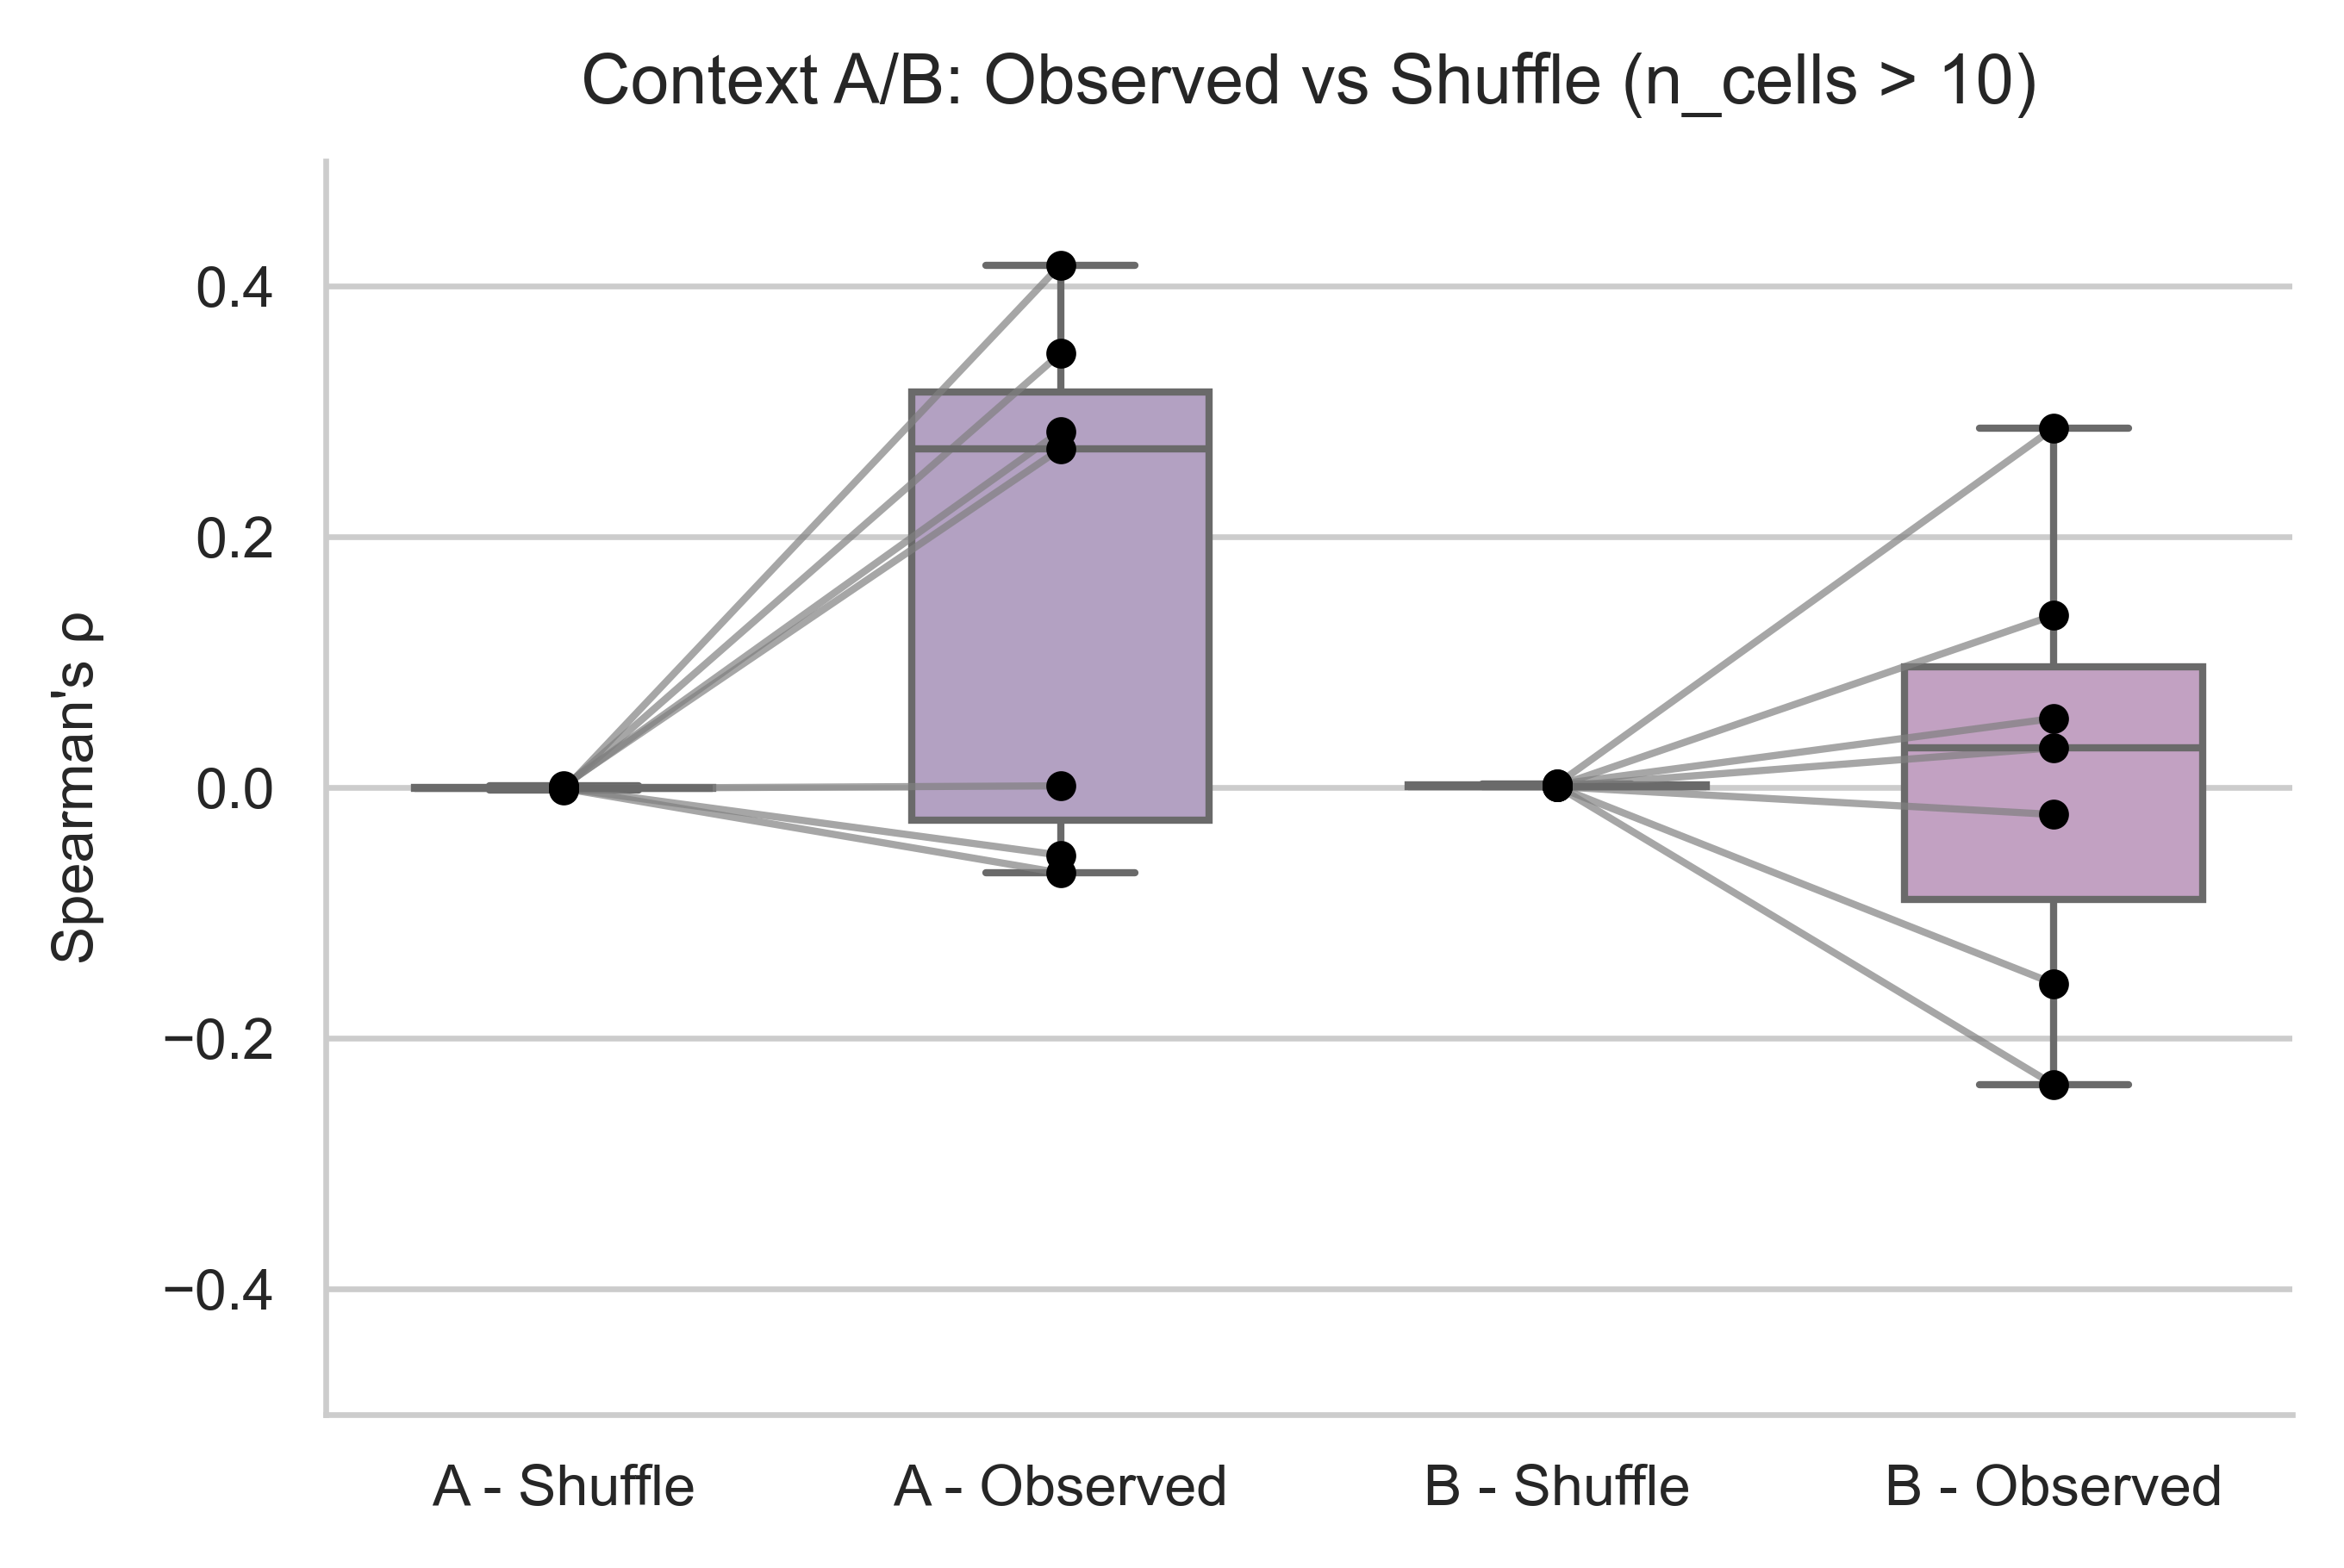

In [26]:
#plot >10 cells by context
fig, ax = boxpaired_two_contexts_vs_shuffle(
    cxta_fig4,
    cxtb_fig4,
    id_col="animal",
    obs_col="rho_obs",
    null_col="null_mean_rho",
    title="Context A/B: Observed vs Shuffle (n_cells > 10)",
    ylim=(-0.5, 0.5),
    save_path="/Users/suthardr/Desktop/Fig4/ctxAB_rho_vs_shuffle_gt10cells.svg"
)

In [29]:
import pandas as pd

fig4_fp = "/Users/suthardr/Desktop/Fig4/shuffle_FC_vs_recall/Fig4_FCvsRecall_shuffle_summary.csv"
df4 = pd.read_csv(fig4_fp)

# Split by context from df4

cxta = df4[df4["context"] == "CxtA"].copy()
cxtb = df4[df4["context"] == "CxtB"].copy()

#rename because im stupid
rename_map = {
    "rho_obs": "spearman_rho",
    "null_mean_rho": "shuffle_null_mean",
    "null_std_rho": "shuffle_null_std",
    "z_obs_vs_null": "shuffle_z",
}

cxta_compat = cxta.rename(columns=rename_map)
cxtb_compat = cxtb.rename(columns=rename_map)

# (optional) reorder columns like Fig3
cols_order = ["animal", "spearman_rho", "shuffle_null_mean", "shuffle_null_std", "shuffle_z"]
cols_order = [c for c in cols_order if c in cxta_compat.columns]  # safety

cxta_compat = cxta_compat[cols_order + [c for c in cxta_compat.columns if c not in cols_order]]
cxtb_compat = cxtb_compat[cols_order + [c for c in cxtb_compat.columns if c not in cols_order]]

#save to filepath as csv
cxta_out_fp = "/Users/suthardr/Desktop/Revision/crossval_summary_results_cxta.csv"
cxtb_out_fp = "/Users/suthardr/Desktop/Revision/crossval_summary_results_cxtb.csv"

cxta_compat.to_csv(cxta_out_fp, index=False)
cxtb_compat.to_csv(cxtb_out_fp, index=False)

print("Saved:")
print("  ", cxta_out_fp)
print("  ", cxtb_out_fp)

Saved:
   /Users/suthardr/Desktop/Revision/crossval_summary_results_cxta.csv
   /Users/suthardr/Desktop/Revision/crossval_summary_results_cxtb.csv


In [23]:
#run t-test on observed vs null for each from saved csv
def compare_rho_vals(cxta_fp, cxtb_fp):
    # read in both csvs
    cxta = pd.read_csv(cxta_fp)
    cxtb = pd.read_csv(cxtb_fp)

    # extract columns
    cxta = cxta[["animal", "spearman_rho", "shuffle_null_mean", "shuffle_null_std", "shuffle_z"]]
    cxtb = cxtb[["animal", "spearman_rho", "shuffle_null_mean", "shuffle_null_std", "shuffle_z"]]

    # paired t-test observed vs null within each context
    stata, pa = stats.ttest_rel(cxta["spearman_rho"], cxta["shuffle_null_mean"])
    statb, pb = stats.ttest_rel(cxtb["spearman_rho"], cxtb["shuffle_null_mean"])

    # between-context comparison of (obs - null)
    diff_a = cxta["spearman_rho"] - cxta["shuffle_null_mean"]
    diff_b = cxtb["spearman_rho"] - cxtb["shuffle_null_mean"]
    stat_diff, p_diff = stats.ttest_ind(diff_a, diff_b, equal_var=False)

    return pa, pb, p_diff, stata, statb, stat_diff

In [24]:
from scipy import stats

#stop running this because it re-writes my csv that i added a sex column to manually
# pa, pb, p_diff, stata, statb, stat_diff = compare_rho_vals(
#     "/Users/suthardr/Desktop/Fig4/crossval_summary_results_cxta.csv",
#     "/Users/suthardr/Desktop/Fig4/crossval_summary_results_cxtb.csv"
# )

#prints stats out for each comp
print("CxtA observed vs shuffle p =", pa, "  t =", stata)
print("CxtB observed vs shuffle p =", pb, "  t =", statb)
print("Between-contexts (A vs B in Δρ) p =", p_diff, "  t =", stat_diff)

CxtA observed vs shuffle p = 0.14643236913759605   t = 1.5626301369723932
CxtB observed vs shuffle p = 0.8422632397855565   t = -0.20556759237167396
Between-contexts (A vs B in Δρ) p = 0.19696806059029662   t = 1.3371943561551052


In [34]:
#boxplot by sex for shuffles
def boxpaired_two_contexts_vs_shuffle_by_sex(
    df_a, df_b,
    id_col="animal",
    sex_col="sex",
    obs_col="spearman_rho",
    null_col="shuffle_null_mean",
    title="Contexts: ρ vs shuffle (by sex)",
    ylim=(0, 1),
    palette=("#C9D6DF", "#B39BC8", "#C9D6DF", "#C79BC8"),
    dpi=600,
        sexes_order=None,
    save_path=None,
):
    """
    One subplot per sex. Each subplot shows four boxes:
      A - Shuffle, A - Observed, B - Shuffle, B - Observed
    Paired lines within A and within B for each animal (no stats, no text).
    """

    # Keep only needed cols and drop NAs
    A = df_a[[id_col, sex_col, obs_col, null_col]].dropna().copy()
    B = df_b[[id_col, sex_col, obs_col, null_col]].dropna().copy()

    # Determine sexes to plot
    if sexes_order is None:
        sexes = sorted(pd.unique(pd.concat([A[sex_col], B[sex_col]], ignore_index=True).dropna()))
    else:
        sexes = [s for s in sexes_order if s in set(pd.unique(pd.concat([A[sex_col], B[sex_col]], ignore_index=True)))]

    # Common mapping/ordering
    name_map = {obs_col: "Observed", null_col: "Shuffle"}
    order = ["A - Shuffle", "A - Observed", "B - Shuffle", "B - Observed"]
    pal = {lab: col for lab, col in zip(order, palette)}
    x_pos = {lab: i for i, lab in enumerate(order)}

    plt.rcParams.update({'font.size': 8, 'font.family': 'Arial'})

    # Figure layout
    n = len(sexes)
    fig, axes = plt.subplots(1, n, figsize=(5.0 * n, 3.5), dpi=dpi, sharey=True)
    if n == 1:
        axes = [axes]

    for ax, sx in zip(axes, sexes):
        A_s = A[A[sex_col] == sx].copy()
        B_s = B[B[sex_col] == sx].copy()

        # Long-form
        A_long = A_s.melt(id_vars=[id_col, sex_col], value_vars=[null_col, obs_col],
                          var_name="condition", value_name="rho")
        B_long = B_s.melt(id_vars=[id_col, sex_col], value_vars=[null_col, obs_col],
                          var_name="condition", value_name="rho")

        A_long["condition"] = A_long["condition"].map(name_map)
        B_long["condition"] = B_long["condition"].map(name_map)
        A_long["label"] = A_long["condition"].map({"Shuffle": "A - Shuffle", "Observed": "A - Observed"})
        B_long["label"] = B_long["condition"].map({"Shuffle": "B - Shuffle", "Observed": "B - Observed"})

        long = pd.concat([A_long, B_long], ignore_index=True)

        # Boxes
        sns.boxplot(
            data=long, x="label", y="rho",
            order=order, palette=pal, ax=ax,
            width=0.6, showfliers=False
        )

        # Paired lines for A (within this sex)
        A_pairs = A_long.pivot_table(index=id_col, columns="condition", values="rho")
        if {"Shuffle", "Observed"}.issubset(A_pairs.columns):
            for _, row in A_pairs.iterrows():
                ax.plot([x_pos["A - Shuffle"], x_pos["A - Observed"]],
                        [row["Shuffle"], row["Observed"]],
                        color="gray", alpha=0.7, linewidth=1)
                ax.scatter([x_pos["A - Shuffle"], x_pos["A - Observed"]],
                           [row["Shuffle"], row["Observed"]],
                           s=10, color="black", zorder=3)

        # Paired lines for B (within this sex)
        B_pairs = B_long.pivot_table(index=id_col, columns="condition", values="rho")
        if {"Shuffle", "Observed"}.issubset(B_pairs.columns):
            for _, row in B_pairs.iterrows():
                ax.plot([x_pos["B - Shuffle"], x_pos["B - Observed"]],
                        [row["Shuffle"], row["Observed"]],
                        color="gray", alpha=0.7, linewidth=1)
                ax.scatter([x_pos["B - Shuffle"], x_pos["B - Observed"]],
                           [row["Shuffle"], row["Observed"]],
                           s=10, color="black", zorder=3)

        # plot pretty
        ax.set_xlabel("")
        ax.set_title(f"{sx}", pad=8)
        if ylim is not None:
            ax.set_ylim(*ylim)
        sns.despine(ax=ax)

    axes[0].set_ylabel("Spearman's ρ", labelpad=8)
    fig.suptitle(title, y=1.02)

    plt.tight_layout(pad=3)

    if save_path:
        fig.savefig(save_path, dpi=dpi, bbox_inches="tight", format=save_path.split(".")[-1])

    return fig, axes


In [49]:
from scipy import stats

#run stats but don't match (paired) for sex
def compare_rho_vals_by_sex_nomatch(
    cxta_fp,
    cxtb_fp,
    sex_col="sex",
    n_cells_min=10,
):
    #grab csv for each context
    cxta = pd.read_csv(cxta_fp)
    cxtb = pd.read_csv(cxtb_fp)

    # filter by n_cells >10
    if "n_cells" in cxta.columns:
        cxta = cxta[cxta["n_cells"] > n_cells_min].copy()
    if "n_cells" in cxtb.columns:
        cxtb = cxtb[cxtb["n_cells"] > n_cells_min].copy()

    keep_cols = [
        "animal", sex_col,
        "spearman_rho",
        "shuffle_null_mean",
        "shuffle_null_std",
        "shuffle_z"
    ]

    cxta = cxta[keep_cols]
    cxtb = cxtb[keep_cols]

    results = {}

    for sex in ["F", "M"]:
        cxta_s = cxta[cxta[sex_col] == sex]
        cxtb_s = cxtb[cxtb[sex_col] == sex]

        ta, pa = stats.ttest_rel(
            cxta_s["spearman_rho"],
            cxta_s["shuffle_null_mean"]
        )

        tb, pb = stats.ttest_rel(
            cxtb_s["spearman_rho"],
            cxtb_s["shuffle_null_mean"]
        )

        diff_a = cxta_s["spearman_rho"] - cxta_s["shuffle_null_mean"]
        diff_b = cxtb_s["spearman_rho"] - cxtb_s["shuffle_null_mean"]

        tdiff, pdiff = stats.ttest_ind(diff_a, diff_b, equal_var=False)
#make a results table
        results[sex] = {
            "n_CxtA": len(cxta_s),
            "n_CxtB": len(cxtb_s),
            "CxtA_obs_vs_shuffle_p": pa,
            "CxtA_obs_vs_shuffle_t": ta,
            "CxtB_obs_vs_shuffle_p": pb,
            "CxtB_obs_vs_shuffle_t": tb,
            "A_vs_B_delta_p": pdiff,
            "A_vs_B_delta_t": tdiff,
        }

    return results


In [50]:
#run function for cxta and b csv files
results_by_sex = compare_rho_vals_by_sex_nomatch(
    "/Users/suthardr/Desktop/Fig4/crossval_summary_results_cxta.csv",
    "/Users/suthardr/Desktop/Fig4/crossval_summary_results_cxtb.csv",
    n_cells_min=10,
)


for sex, res in results_by_sex.items():
    print(f"\nSEX = {sex}")
    print("n CxtA =", res["n_CxtA"], " n CxtB =", res["n_CxtB"])
    print("CxtA obs vs shuffle: p =", res["CxtA_obs_vs_shuffle_p"],
          " t =", res["CxtA_obs_vs_shuffle_t"])
    print("CxtB obs vs shuffle: p =", res["CxtB_obs_vs_shuffle_p"],
          " t =", res["CxtB_obs_vs_shuffle_t"])
    print("A vs B (Δρ): p =", res["A_vs_B_delta_p"],
          " t =", res["A_vs_B_delta_t"])



SEX = F
n CxtA = 3  n CxtB = 3
CxtA obs vs shuffle: p = 0.6351715095652033  t = 0.5541396158866434
CxtB obs vs shuffle: p = 0.37333680466761043  t = 1.1372343351852552
A vs B (Δρ): p = 0.8667663713703776  t = -0.1803585683793445

SEX = M
n CxtA = 4  n CxtB = 4
CxtA obs vs shuffle: p = 0.06853026382427319  t = 2.7880435775121333
CxtB obs vs shuffle: p = 0.5528794213921753  t = -0.6662989051120931
A vs B (Δρ): p = 0.0493641453484602  t = 2.4565489828574862


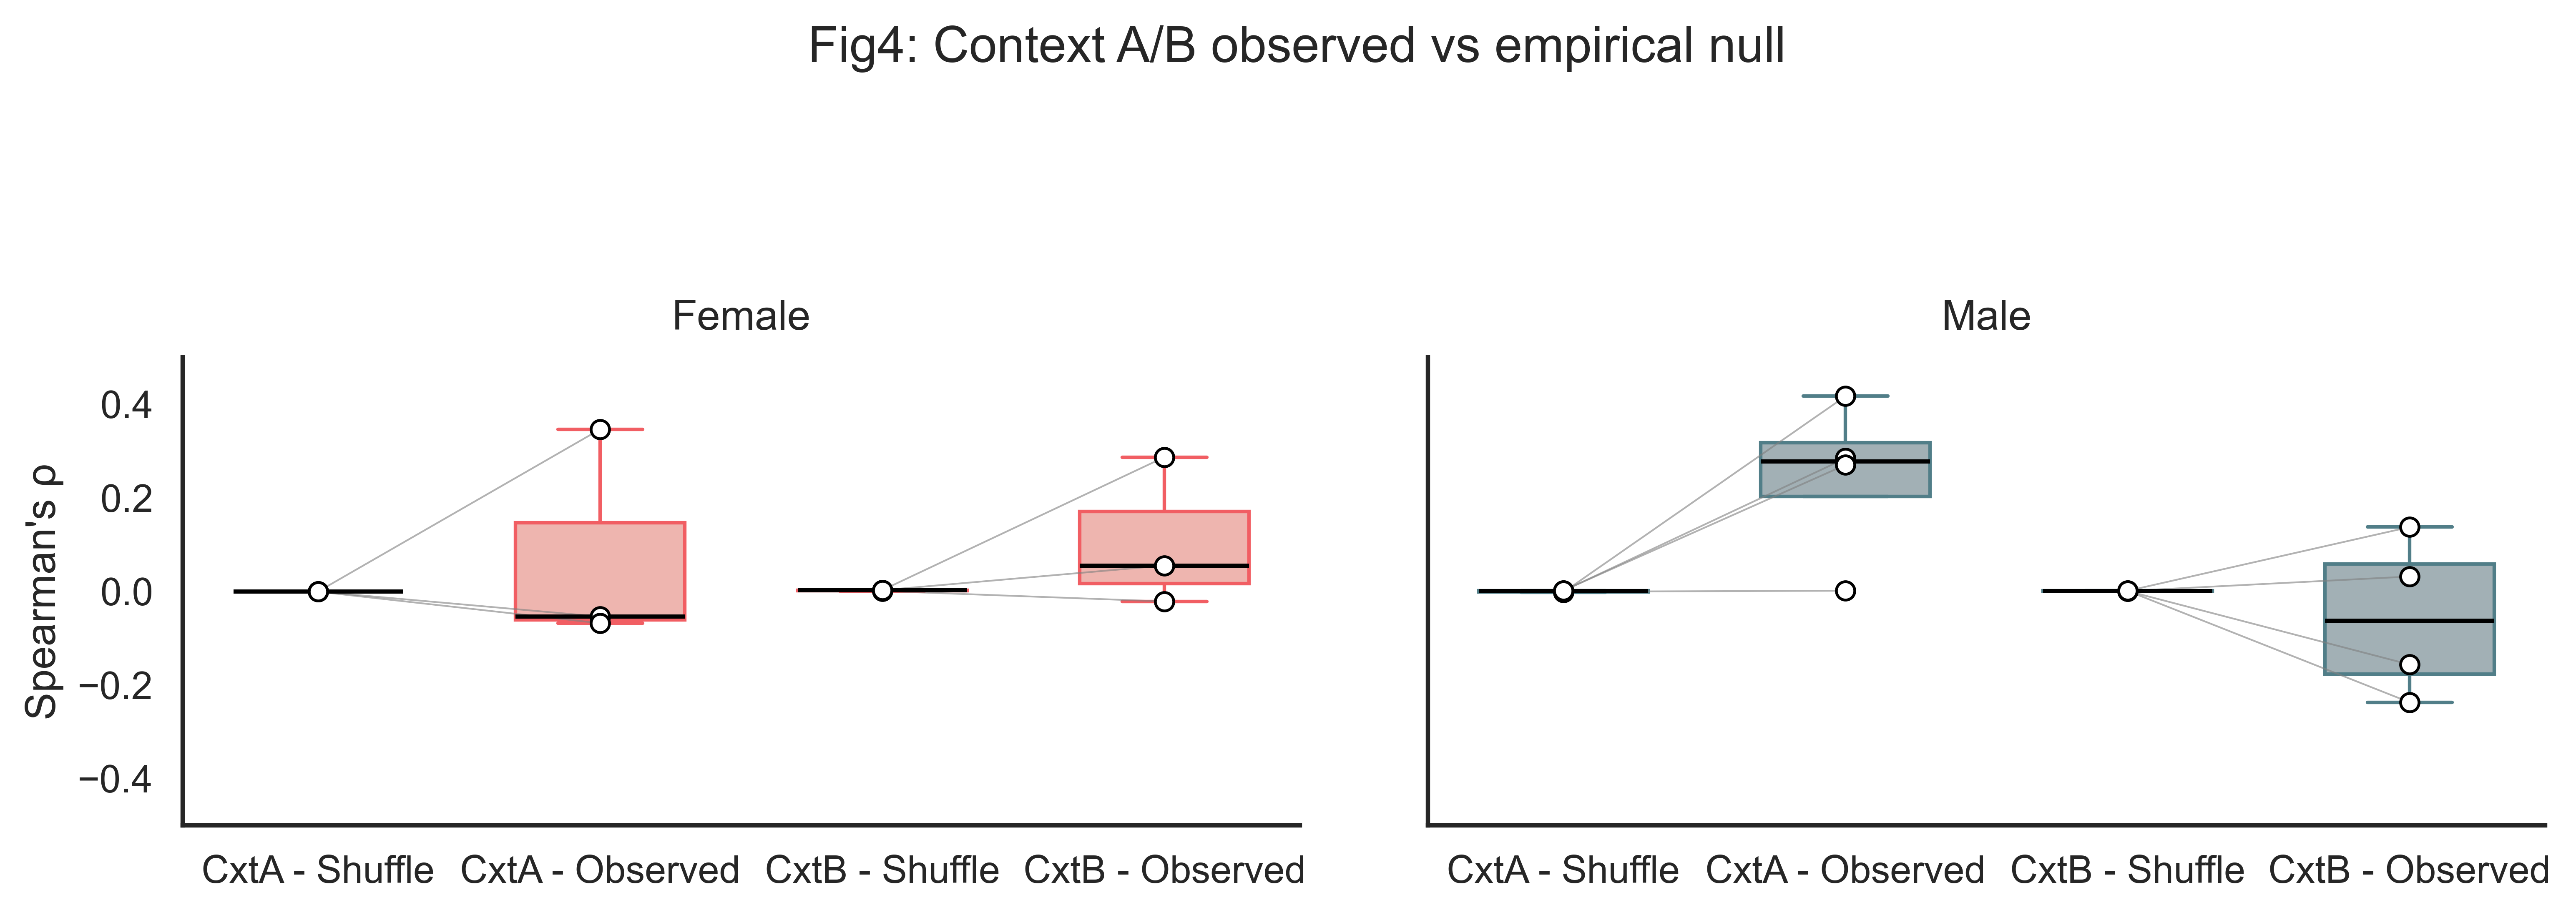

In [66]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import matplotlib as mpl

mpl.rcParams["svg.fonttype"] = "none"
mpl.rcParams["font.family"] = "Arial"

def boxpaired_fig4_ctxAB_vs_shuffle_panelsBySex(
    cxta_fp,
    cxtb_fp,
    id_col="animal",
    sex_col="sex",
    obs_col="spearman_rho",
    null_col="shuffle_null_mean",
    n_cells_min=10,
    title="Fig4: Context A/B observed vs empirical null",
    ylim=(-0.5, 0.5),
    dpi=600,
    save_path=None,
):
    plt.rcParams.update({
        "font.family": "Arial",
        "font.size": 11,
        "axes.edgecolor": "black",
        "axes.linewidth": 1.0,
        "axes.grid": False,
        "xtick.color": "black",
        "ytick.color": "black",
        "xtick.major.width": 1.0,
        "ytick.major.width": 1.0,
        "xtick.major.size": 5,
        "ytick.major.size": 5,
    })
    sns.set(style="white")  # no grid

    cxta = pd.read_csv(cxta_fp)
    cxtb = pd.read_csv(cxtb_fp)

    if "n_cells" in cxta.columns:
        cxta = cxta[cxta["n_cells"] > n_cells_min].copy()
    if "n_cells" in cxtb.columns:
        cxtb = cxtb[cxtb["n_cells"] > n_cells_min].copy()

    cxta[obs_col] = pd.to_numeric(cxta[obs_col], errors="coerce")
    cxta[null_col] = pd.to_numeric(cxta[null_col], errors="coerce")
    cxtb[obs_col] = pd.to_numeric(cxtb[obs_col], errors="coerce")
    cxtb[null_col] = pd.to_numeric(cxtb[null_col], errors="coerce")

    sex_style = {
        "F": {"face": "#f8aca4", "edge": "#f15e63"},
        "M": {"face": "#9fb1b8", "edge": "#517e88"},
    }

    def _to_long(df, ctx):
        d = df[[id_col, sex_col, obs_col, null_col]].dropna().copy()
        long = d.melt(
            id_vars=[id_col, sex_col],
            value_vars=[null_col, obs_col],
            var_name="condition",
            value_name="rho"
        )
        long["condition"] = long["condition"].map(
            {null_col: "Shuffle", obs_col: "Observed"}
        )
        long["label"] = long["condition"].map({
            "Shuffle": f"{ctx} - Shuffle",
            "Observed": f"{ctx} - Observed"
        })
        return long

    long = pd.concat(
        [_to_long(cxta, "CxtA"), _to_long(cxtb, "CxtB")],
        ignore_index=True
    )

    order = ["CxtA - Shuffle", "CxtA - Observed", "CxtB - Shuffle", "CxtB - Observed"]
    x_pos = {lab: i for i, lab in enumerate(order)}

    sexes_present = [s for s in ["F", "M"] if s in set(long[sex_col].dropna().unique())]
    if len(sexes_present) == 0:
        raise ValueError(f"No valid sex values found in column '{sex_col}' after filtering/dropna().")

#plot
    fig, axes = plt.subplots(
        1, len(sexes_present),
        figsize=(5.5 * len(sexes_present), 3.8),
        dpi=dpi,
        sharey=True
    )
    if len(sexes_present) == 1:
        axes = [axes]

    for ax, sex in zip(axes, sexes_present):
        dsex = long[long[sex_col] == sex].copy()

        face = sex_style.get(sex, {"face": "lightgray"})["face"]
        edge = sex_style.get(sex, {"edge": "black"})["edge"]

        sns.boxplot(
            data=dsex,
            x="label",
            y="rho",
            order=order,
            color=face,
            width=0.6,
            showfliers=False,
            ax=ax,
            medianprops=dict(color="black", linewidth=1.2),
            boxprops=dict(edgecolor=edge, linewidth=1),
            whiskerprops=dict(color=edge, linewidth=1),
            capprops=dict(color=edge, linewidth=1),
        )

        for patch in ax.artists:
            patch.set_alpha(0.6)

        #paired lines
        for ctx in ["CxtA", "CxtB"]:
            shuf = f"{ctx} - Shuffle"
            obs = f"{ctx} - Observed"

            pairs = dsex.pivot_table(index=id_col, columns="label", values="rho", aggfunc="mean")

            if shuf in pairs.columns and obs in pairs.columns:
                # keep only rows where both exist and are finite
                pair_df = pairs[[shuf, obs]].dropna()
                pair_df = pair_df[np.isfinite(pair_df[shuf]) & np.isfinite(pair_df[obs])]

                for _, row in pair_df.iterrows():
                    y0 = float(row[shuf])
                    y1 = float(row[obs])

                    ax.plot(
                        [x_pos[shuf], x_pos[obs]],
                        [y0, y1],
                        color="gray",
                        alpha=0.6,
                        linewidth=0.5,
                        zorder=2
                    )
                    ax.scatter(
                        [x_pos[shuf], x_pos[obs]],
                        [y0, y1],
                        s=28,
                        facecolors="white",
                        edgecolors="black",
                        linewidths=0.8,
                        zorder=3
                    )

        ax.set_xticks(range(len(order)))
        ax.set_xticklabels(order, rotation=0)
        ax.tick_params(axis="both", which="major", labelsize=11, width=1.0, length=5, direction="out")
        ax.grid(False)

        ax.set_title("Female" if sex == "F" else "Male", pad=8)
        ax.set_xlabel("")
        if ylim is not None:
            ax.set_ylim(*ylim)

        sns.despine(ax=ax)

    axes[0].set_ylabel("Spearman's ρ")
    fig.suptitle(title, y=1.02)
    plt.tight_layout(pad=2.5)

    if save_path:
        fig.savefig(save_path, format = 'svg', dpi=dpi, bbox_inches="tight")

    return fig, axes

fig, axes = boxpaired_fig4_ctxAB_vs_shuffle_panelsBySex(
    cxta_fp="/Users/suthardr/Desktop/Fig4/crossval_summary_results_cxta.csv",
    cxtb_fp="/Users/suthardr/Desktop/Fig4/crossval_summary_results_cxtb.csv",
    save_path="/Users/suthardr/Desktop/Fig4/fig4_ctxAB_rho_vs_shuffle_panelsBySex_FINAL.svg",
    title="Fig4: Context A/B observed vs empirical null",
    ylim=(-0.5, 0.5),
)
